# Intro

In the previous blog post, we talked about the intuition behind GANs (Generative Adversarial Networks), how they work, and how to create a simple GAN model capable of learning how to generate images that look a lot like images from the MNIST and SVHNs datasets. Now, let us turn the wheels a little and talk about one of the most prominent applications of GANs, semi-supervised learning.

In [87]:
# Lets start by loading the necessary libraries
%matplotlib inline

import pickle as pkl
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import tensorflow as tf
import os
import tensorflow.compat.v1 as tfv1
# Use second GPU -- change if you want to use a first one
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

In [88]:
tfv1.disable_eager_execution()

In [89]:
!mkdir data

A subdirectory or file data already exists.


For these first cells, we are going to download the SVHN dataset files and preprocess them.

In [90]:
impath = 'xenobirds_spec_images'
image_paths = [os.path.join(impath, f) for f in os.listdir(impath)]
image_path_classes = [im[:-4].split('_')[-1] for im in image_paths]
im_classes = list(set(image_path_classes))

In [91]:
from PIL import Image
import cv2

In [92]:
imagesX = [np.array(Image.open(fname))[:,:,:1] for fname in image_paths]
#imagesX = [cv2.resize(img, dsize=(32, 32), interpolation=cv2.INTER_CUBIC) for img in imagesX]
imagesX = np.array(imagesX)

In [93]:
imagesX.shape

(1792, 217, 334, 1)

In [94]:
im_classes.sort()
im_classes

['Blackbird',
 'Chaffinch',
 'Dunnock',
 'Goldfinch',
 'Linnet',
 'Robin',
 'Rook',
 'Starling',
 'Stonechat',
 'Wren',
 'Yellowhammer']

In [95]:
imagesY = [im_classes.index(f) for f in image_path_classes]
imagesY = np.reshape(imagesY, (-1,1))

In [96]:
from sklearn.model_selection import train_test_split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(imagesX, imagesY, test_size=0.1, random_state=42, stratify = imagesY)

In [98]:
X_train = np.moveaxis(X_train, 0, -1)
X_test = np.moveaxis(X_test, 0, -1)
y_train

array([[ 2],
       [10],
       [ 2],
       ...,
       [ 5],
       [ 1],
       [ 3]])

In [99]:
# Load the training and testing datasets
trainset = dict({'X': X_train,
                'y': y_train})
testset = dict({'X': X_test,
                'y': y_test})
#trainset = loadmat(data_dir + 'train_32x32.mat')
#testset = loadmat(data_dir + 'test_32x32.mat')
print("trainset shape:", trainset['X'].shape)
print("testset shape:", testset['X'].shape)

trainset shape: (217, 334, 1, 1612)
testset shape: (217, 334, 1, 180)


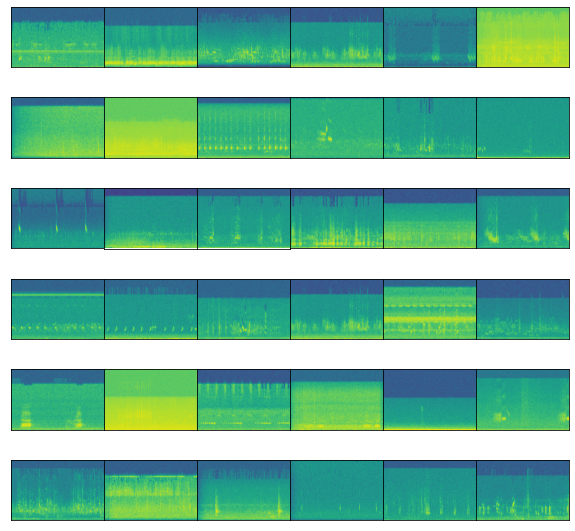

In [100]:
# Let's just take a pick in some of the SVHN samples the network will process
idx = np.random.randint(0, trainset['X'].shape[3], size=36)
fig, axes = plt.subplots(6, 6, sharex=True, sharey=True, figsize=(10,10),)
for ii, ax in zip(idx, axes.flatten()):
    ax.imshow(trainset['X'][:,:,:,ii], aspect='equal')
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
plt.subplots_adjust(wspace=0, hspace=0)

Scales the image pixel values to the range of -1 to 1. That is necessary because the Generator net outputs values squashed between this range through the Tanh() function.

In [101]:
def scale(x, feature_range=(-1, 1)):
    # scale to (0, 1)
    x = ((x - x.min())/(255 - x.min()))
    
    # scale to feature_range
    min, max = feature_range
    x = x * (max - min) + min
    return x

In [102]:
class Dataset:
    def __init__(self, train, test, val_frac=0.5, shuffle=True, scale_func=None):
        split_idx = int(len(test['y'])*(1 - val_frac))
        self.test_x, self.valid_x = test['X'][:,:,:,:split_idx], test['X'][:,:,:,split_idx:]
        self.test_y, self.valid_y = test['y'][:split_idx], test['y'][split_idx:]
        self.train_x, self.train_y = train['X'], train['y']
        # The SVHN dataset comes with lots of labels, but for the purpose of this exercise,
        # we will pretend that there are only 1000.
        # We use this mask to say which labels we will allow ourselves to use.
        self.label_mask = np.zeros_like(self.train_y)
        self.label_mask[0:1000] = 1
        
        # Roll the specified axis backwards, until it lies in a given position.
        # From (32, 32, 3, 73257) to (73257, 32, 32, 3)
        self.train_x = np.rollaxis(self.train_x, axis=3)
        self.valid_x = np.rollaxis(self.valid_x, axis=3)
        self.test_x = np.rollaxis(self.test_x, axis=3)
        
        if scale_func is None:
            self.scaler = scale
        else:
            self.scaler = scale_func
        self.train_x = self.scaler(self.train_x)
        self.valid_x = self.scaler(self.valid_x)
        self.test_x = self.scaler(self.test_x)
        self.shuffle = shuffle
        
    def batches(self, batch_size, which_set="train"):
        x_name = which_set + "_x"
        y_name = which_set + "_y"

        # Return the value of the named attribute of object
        num_examples = len(getattr(dataset, y_name))
        if self.shuffle:
            idx = np.arange(num_examples)
            np.random.shuffle(idx)
            setattr(dataset, x_name, getattr(dataset, x_name)[idx])
            setattr(dataset, y_name, getattr(dataset, y_name)[idx])
            if which_set == "train":
                dataset.label_mask = dataset.label_mask[idx]
        
        dataset_x = getattr(dataset, x_name)
        dataset_y = getattr(dataset, y_name)
        for ii in range(0, num_examples, batch_size):
            x = dataset_x[ii:ii+batch_size]
            y = dataset_y[ii:ii+batch_size]
            
            if which_set == "train":
                # When we use the data for training, we need to include
                # the label mask, so we can pretend we don't have access
                # to some of the labels, as an exercise of our semi-supervised
                # learning ability
                # x: [BATCH_SIZE, 32, 32, 3]
                # y: [BATCH_SIZE, 1]
                # label_mask: [BATCH_SIZE, 1] whether a 0: Label Cannot be used or 1: Label can be used 
                yield x, y, self.label_mask[ii:ii+batch_size]
            else:
                yield x, y

In [103]:
def model_inputs(real_dim, z_dim):
    # placeholder for inputing the real images from the training set to the discriminator 
    inputs_real = tfv1.placeholder(tf.float32, (None, *real_dim), name='input_real')
    
    # placeholder for inputing random noise data into the discriminator
    inputs_z = tfv1.placeholder(tf.float32, (None, z_dim), name='input_z')
    
    # placeholder for inputing the real data labels (0-9 for the SVHN dataset)
    y = tfv1.placeholder(tf.int32, (None), name='y')
    
    # placeholder for inputing the label masks which tell the model for which 
    # sample images should it take the labels for training
    label_mask = tfv1.placeholder(tf.int32, (None), name='label_mask')
    
    return inputs_real, inputs_z, y, label_mask

## Generator


For the generator we follow a very basic implementation described in the DCGAN paper. This approach consists reshaping a random vector z to have a 4D shape and then feed it to a sequence of transpose convolutions, batch normalization and leaky RELU operations that increase the spatial dimensions of the input vector while decreases the number of channels. As a result, the Network outputs a 32x32x3 tensor shape that is squashed between values of -1 and 1 through the Hyperbolic Tangent Function. 

In [104]:
tf.compat.v1.layers.batch_normalization

<function keras.legacy_tf_layers.normalization.batch_normalization(inputs, axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True, beta_initializer=<tensorflow.python.ops.init_ops.Zeros object at 0x0000020AFBA02BE0>, gamma_initializer=<tensorflow.python.ops.init_ops.Ones object at 0x0000020AFBA02C10>, moving_mean_initializer=<tensorflow.python.ops.init_ops.Zeros object at 0x0000020AFBA02CD0>, moving_variance_initializer=<tensorflow.python.ops.init_ops.Ones object at 0x0000020AFBA02D30>, beta_regularizer=None, gamma_regularizer=None, beta_constraint=None, gamma_constraint=None, training=False, trainable=True, name=None, reuse=None, renorm=False, renorm_clipping=None, renorm_momentum=0.99, fused=None, virtual_batch_size=None, adjustment=None)>

In [105]:
def generator(z, output_dim, reuse=False, alpha=0.2, training=True, size_mult=128):
    with tfv1.variable_scope('generator', reuse=reuse):
        x1 = tfv1.layers.dense(z, 4 * 4 * size_mult * 4)
        # Reshape it to start the convolutional stack
        x1 = tfv1.reshape(x1, (-1, 4, 4, size_mult * 4))
        x1 = tfv1.layers.batch_normalization(x1, training=training)
        x1 = tfv1.maximum(alpha * x1, x1)
        
        x2 = tfv1.layers.conv2d_transpose(x1, size_mult * 2, 5, strides=2, padding='same')
        x2 = tfv1.layers.batch_normalization(x2, training=training)
        x2 = tfv1.maximum(alpha * x2, x2)
        
        x3 = tfv1.layers.conv2d_transpose(x2, size_mult, 5, strides=2, padding='same')
        x3 = tfv1.layers.batch_normalization(x3, training=training)
        x3 = tfv1.maximum(alpha * x3, x3)
        
        # Output layer
        logits = tfv1.layers.conv2d_transpose(x3, output_dim, 5, strides=2, padding='same')
        
        out = tfv1.tanh(logits)
        # First fully connected layer
        #x1 = tf.keras.layers.Dense(4 * 4 * size_mult * 4)(z)
        # Reshape it to start the convolutional stack
        #x1 = tf.keras.layers.Reshape((-1, 4, 4, size_mult * 4))(x1)
        #x1 = tf.keras.layers.BatchNormalization()(x1, training=training)
        #x1 = tf.maximum(alpha * x1, x1)
        
        #x2 = tf.keras.layers.Conv2DTranspose(size_mult * 2, 5, strides=2, padding='same')(x1)
        #x2 = tf.keras.layers.BatchNormalization()(x2, training=training)
        #x2 = tf.maximum(alpha * x2, x2)

        #x3 = tf.keras.layers.Conv2DTranspose(size_mult, 5, strides=2, padding='same')(x2)
        #x3 = tf.keras.layers.BatchNormalization()(x3, training=training)
        #x3 = tf.maximum(alpha * x3, x3)
        
        # Output layer
        #logits = tf.keras.layers.Conv2DTranspose(output_dim, 5, strides=2, padding='same')(x3)
        
        #out = tf.tanh(logits)
        
        return out

## Discriminator

Here we setup an also similar DCGAN architecture in which we use a stack of strided 2 convolutions for dimensionality reduction and batch normalization for stabilizing learning (except for the first layer of the network).

The 2D convolution window (kernel or filter) is set to have a width and height of 5 across all the convolution operations. Also, note that we have some layers with dropout. It is important to understand that our discriminator behaves (in part) like any other regular classifier and because of that; it may suffers from the same problems any classifier would if not well designed.

After a series of convolutions, batch normalization, leaky RELUs and dropout, instead of directly applying a fully connected layer on top of the convolutions, we perform a Global Average Pooling (GAP) operation.

In [106]:
def discriminator(x, reuse=False, alpha=0.2, drop_rate=0., num_classes=10, size_mult=64):
    with tfv1.variable_scope('discriminator', reuse=reuse):
        x = tfv1.layers.dropout(x, rate=drop_rate/2.5)
        
        # Input layer is ?x32x32x3
        x1 = tfv1.layers.conv2d(x, size_mult, 3, strides=2, padding='same')
        relu1 = tfv1.maximum(alpha * x1, x1)
        relu1 = tfv1.layers.dropout(relu1, rate=drop_rate) # [?x16x16x?]

        x2 = tfv1.layers.conv2d(relu1, size_mult, 3, strides=2, padding='same')
        bn2 = tfv1.layers.batch_normalization(x2, training=True) # [?x8x8x?]
        relu2 = tfv1.maximum(alpha * bn2, bn2)
        
        x3 = tfv1.layers.conv2d(relu2, size_mult, 3, strides=2, padding='same') # [?x4x4x?]
        bn3 = tfv1.layers.batch_normalization(x3, training=True)
        relu3 = tfv1.maximum(alpha * bn3, bn3)
        relu3 = tfv1.layers.dropout(relu3, rate=drop_rate)
        
        x4 = tfv1.layers.conv2d(relu3, 2 * size_mult, 3, strides=1, padding='same') # [?x4x4x?]
        bn4 = tfv1.layers.batch_normalization(x4, training=True)
        relu4 = tfv1.maximum(alpha * bn4, bn4)
        
        x5 = tfv1.layers.conv2d(relu4, 2 * size_mult, 3, strides=1, padding='same') # [?x4x4x?]
        bn5 = tfv1.layers.batch_normalization(x5, training=True)
        relu5 = tfv1.maximum(alpha * bn5, bn5)

        x6 = tfv1.layers.conv2d(relu5, 2 * size_mult, 3, strides=2, padding='same') # [?x2x2x?]
        bn6 = tfv1.layers.batch_normalization(x6, training=True)
        relu6 = tfv1.maximum(alpha * bn6, bn6)
        relu6 = tfv1.layers.dropout(relu6, rate=drop_rate)
        
        x7 = tfv1.layers.conv2d(relu5, filters=(2 * size_mult), kernel_size=3, strides=1, padding='valid')
        #x = tf.keras.layers.Dropout(drop_rate/2.5)(x)
        
        # Input layer is ?x32x32x3
        #x1 = tf.keras.layers.Conv2D(size_mult, 3, strides=2, padding='same')(x)
        #relu1 = tf.maximum(alpha * x1, x1)
        #relu1 = tf.keras.layers.Dropout(drop_rate)(relu1) # [?x16x16x?]

        #x2 = tf.keras.layers.Conv2D(size_mult, 3, strides=2, padding='same')(relu1)
        #bn2 = tf.keras.layers.BatchNormalization()(x2, training=True) # [?x8x8x?]
        #relu2 = tf.maximum(alpha * bn2, bn2)
        
        #x3 = tf.keras.layers.Conv2D(size_mult, 3, strides=2, padding='same')(relu2) # [?x4x4x?]
        #bn3 = tf.keras.layers.BatchNormalization()(x3, training=True)
        #relu3 = tf.maximum(alpha * bn3, bn3)
        #relu3 = tf.keras.layers.Dropout(drop_rate)(relu3)
        
        #x4 = tf.keras.layers.Conv2D(2 * size_mult, 3, strides=1, padding='same')(relu3) # [?x4x4x?]
        #bn4 = tf.keras.layers.BatchNormalization()(x4, training=True)
        #relu4 = tf.maximum(alpha * bn4, bn4)
        
        #x5 = tf.keras.layers.Conv2D(2 * size_mult, 3, strides=1, padding='same')(relu4) # [?x4x4x?]
        #bn5 = tf.keras.layers.BatchNormalization()(x5, training=True)
        #relu5 = tf.maximum(alpha * bn5, bn5)

        #x6 = tf.keras.layers.Conv2D(2 * size_mult, 3, strides=2, padding='same')(relu5) # [?x2x2x?]
        #bn6 = tf.keras.layers.BatchNormalization()(x6, training=True)
        #relu6 = tf.maximum(alpha * bn6, bn6)
        #relu6 = tf.keras.layers.Dropout(drop_rate)(relu6)
        
        #x7 = tf.keras.layers.Conv2D(filters=(2 * size_mult), kernel_size=3, strides=1, padding='valid')(relu5)
        # Don't use bn on this layer, because bn would set the mean of each feature
        # to the bn mu parameter.
        # This layer is used for the feature matching loss, which only works if
        # the means can be different when the discriminator is run on the data than
        # when the discriminator is run on the generator samples.
        relu7 = tf.maximum(alpha * x7, x7)
        
        # Flatten it by global average pooling
        # In global average pooling, for every feature map we take the average over all the spatial
        # domain and return a single value
        # In: [BATCH_SIZE,HEIGHT X WIDTH X CHANNELS] --> [BATCH_SIZE, CHANNELS]
        features = tf.reduce_mean(relu7, axis=[1,2])
        
        # Set class_logits to be the inputs to a softmax distribution over the different classes
        #class_logits = tf.keras.layers.Dense(num_classes)(features)
        class_logits = tfv1.layers.dense(features, num_classes)
        # This function is more numerically stable than log(sum(exp(input))). 
        # It avoids overflows caused by taking the exp of large inputs and underflows 
        # caused by taking the log of small inputs.
        gan_logits = tf.reduce_logsumexp(class_logits, 1)
        
        # Get the probability that the input is real rather than fake
        out = tf.nn.softmax(class_logits) # class probabilities for the 10 real classes plus the fake class
        
        return out, class_logits, gan_logits, features

In [107]:
def model_loss(input_real, input_z, output_dim, y, num_classes, label_mask, alpha=0.2, drop_rate=0., smooth=0.1):
    """
    Get the loss for the discriminator and generator
    :param input_real: Images from the real dataset
    :param input_z: Z input random noise vector 
    :param output_dim: The number of channels in the output image
    :param y: Integer class labels
    :param num_classes: The number of classes
    :param alpha: The slope of the left half of leaky ReLU activation
    :param drop_rate: The probability of dropping a hidden unit
    :return: A tuple of (discriminator loss, generator loss)
    """
    
    # These numbers multiply the size of each layer of the generator and the discriminator,
    # respectively. You can reduce them to run your code faster for debugging purposes.
    g_size_mult = 32
    d_size_mult = 64
    
    # Here we instatiate the generator and the discriminator networks
    g_model = generator(input_z, output_dim, alpha=alpha, size_mult=g_size_mult)
    d_on_data = discriminator(input_real, alpha=alpha, drop_rate=drop_rate, size_mult=d_size_mult)
    
    # d_model_real: probability that the input is real
    # class_logits_on_data: the unnormalized log probability values for the probability of each classe
    # gan_logits_on_data: the probability of whether or not the image is real
    # data_features: features from the last layer of the discriminator to be used in the feature matching loss
    d_model_real, class_logits_on_data, gan_logits_on_data, data_features = d_on_data
    
    d_on_samples = discriminator(g_model, reuse=True, alpha=alpha, drop_rate=drop_rate, size_mult=d_size_mult)
    d_model_fake, class_logits_on_samples, gan_logits_on_samples, sample_features = d_on_samples
    
    # Here we compute `d_loss`, the loss for the discriminator.
    # This should combine two different losses:
    # 1. The loss for the GAN problem, where we minimize the cross-entropy for the binary
    #    real-vs-fake classification problem.
    real_data_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=gan_logits_on_data, 
                                                            labels=tf.ones_like(gan_logits_on_data) * (1 - smooth)))
    
    fake_data_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(logits=gan_logits_on_samples, 
                                                         labels=tf.zeros_like(gan_logits_on_samples)))
    
    unsupervised_loss = real_data_loss + fake_data_loss
    
    #  2. The loss for the SVHN digit classification problem, where we minimize the cross-entropy
    #     for the multi-class softmax. For this one we use the labels. Don't forget to ignore
    #     use `label_mask` to ignore the examples that we are pretending are unlabeled for the
    #     semi-supervised learning problem.
    y = tf.squeeze(y)
    suppervised_loss = tf.nn.softmax_cross_entropy_with_logits(logits=class_logits_on_data,
                                                                  labels=tf.one_hot(y, num_classes, dtype=tf.float32))
    
    label_mask = tf.squeeze(tfv1.to_float(label_mask))
    
    # ignore the labels that we pretend does not exist for the loss
    suppervised_loss = tf.reduce_sum(tf.multiply(suppervised_loss, label_mask))
    
    # get the mean 
    suppervised_loss = suppervised_loss / tf.maximum(1.0, tf.reduce_sum(label_mask))
    d_loss = unsupervised_loss + suppervised_loss
    
    # Here we set `g_loss` to the "feature matching" loss invented by Tim Salimans at OpenAI.
    # This loss consists of minimizing the absolute difference between the expected features
    # on the data and the expected features on the generated samples.
    # This loss works better for semi-supervised learning than the tradition GAN losses.
    
    # Make the Generator output features that are on average similar to the features 
    # that are found by applying the real data to the discriminator
    
    data_moments = tf.reduce_mean(data_features, axis=0)
    sample_moments = tf.reduce_mean(sample_features, axis=0)
    g_loss = tf.reduce_mean(tf.abs(data_moments - sample_moments))

    pred_class = tf.cast(tf.argmax(class_logits_on_data, 1), tf.int32)
    eq = tf.equal(tf.squeeze(y), pred_class)
    correct = tf.reduce_sum(tfv1.to_float(eq))
    masked_correct = tf.reduce_sum(label_mask * tfv1.to_float(eq))
    
    return d_loss, g_loss, correct, masked_correct, g_model

In [108]:
def model_opt(d_loss, g_loss, learning_rate, beta1):
    """
    Get optimization operations
    :param d_loss: Discriminator loss Tensor
    :param g_loss: Generator loss Tensor
    :param learning_rate: Learning Rate Placeholder
    :param beta1: The exponential decay rate for the 1st moment in the optimizer
    :return: A tuple of (discriminator training operation, generator training operation)
    """
    # Get weights and biases to update. Get them separately for the discriminator and the generator
    discriminator_train_vars = tfv1.get_collection(tfv1.GraphKeys.TRAINABLE_VARIABLES , scope='discriminator')
    generator_train_vars = tfv1.get_collection(tfv1.GraphKeys.TRAINABLE_VARIABLES, scope='generator')
    
    # Minimize both players' costs simultaneously
    #update_ops = tf.get_collection(tf.GraphKeys.UPDATE_OPS)
    #with tf.control_dependencies(update_ops):
    d_train_opt = tfv1.train.AdamOptimizer(learning_rate, beta1, name='d_optimizer').minimize(d_loss, var_list=discriminator_train_vars)
    g_train_opt = tfv1.train.AdamOptimizer(learning_rate, beta1, name='g_optimizer').minimize(g_loss, var_list=generator_train_vars)

    shrink_lr = tfv1.assign(learning_rate, learning_rate * 0.9)
    
    return d_train_opt, g_train_opt, shrink_lr

In [109]:
class GAN:
    """
    A GAN model.
    :param real_size: The shape of the real data.
    :param z_size: The number of entries in the z code vector.
    :param learnin_rate: The learning rate to use for Adam.
    :param num_classes: The number of classes to recognize.
    :param alpha: The slope of the left half of the leaky ReLU activation
    :param beta1: The beta1 parameter for Adam.
    """
    def __init__(self, real_size, z_size, learning_rate, num_classes=10, alpha=0.2, beta1=0.5):
        tfv1.reset_default_graph()
        
        self.learning_rate = tf.Variable(learning_rate, trainable=False)
        inputs = model_inputs(real_size, z_size)
        self.input_real, self.input_z, self.y, self.label_mask = inputs
        self.drop_rate = tfv1.placeholder_with_default(.5, (), "drop_rate")
        
        loss_results = model_loss(self.input_real, self.input_z,
                                  real_size[2], self.y, num_classes,
                                  label_mask=self.label_mask,
                                  alpha=0.2,
                                  drop_rate=self.drop_rate)
        self.d_loss, self.g_loss, self.correct, self.masked_correct, self.samples = loss_results
        
        self.d_opt, self.g_opt, self.shrink_lr = model_opt(self.d_loss, self.g_loss, self.learning_rate, beta1)

In [110]:
def view_samples(epoch, samples, nrows, ncols, figsize=(5,5)):
    fig, axes = plt.subplots(figsize=figsize, nrows=nrows, ncols=ncols, 
                             sharey=True, sharex=True)
    for ax, img in zip(axes.flatten(), samples[epoch]):
        ax.axis('off')
        img = ((img - img.min())*255 / (img.max() - img.min())).astype(np.uint8)
        ax.set_adjustable('box')#-forced')
        im = ax.imshow(img)
   
    plt.subplots_adjust(wspace=0, hspace=0)
    return fig, axes

In [111]:
def train(net, dataset, epochs, batch_size, figsize=(5,5)):
    
    saver = tfv1.train.Saver()
    sample_z = np.random.normal(0, 1, size=(50, z_size))

    samples, train_accuracies, test_accuracies = [], [], []
    steps = 0

    with tfv1.Session() as sess:
        sess.run(tfv1.global_variables_initializer())
        for e in range(epochs):
            print("Epoch",e)
            
            t1e = time.time()
            num_examples = 0
            num_correct = 0
            for x, y, label_mask in dataset.batches(batch_size):
                assert 'int' in str(y.dtype)
                steps += 1
                num_examples += label_mask.sum()

                # Sample random noise for G
                batch_z = np.random.normal(0, 1, size=(batch_size, z_size))

                # Run optimizers
                t1 = time.time()
                _, _, correct = sess.run([net.d_opt, net.g_opt, net.masked_correct],
                                         feed_dict={net.input_real: x, net.input_z: batch_z,
                                                    net.y : y, net.label_mask : label_mask})
                t2 = time.time()
                num_correct += correct

            sess.run([net.shrink_lr])
            
            
            train_accuracy = num_correct / float(num_examples)
            
            print("\t\tClassifier train accuracy: ", train_accuracy)
            
            num_examples = 0
            num_correct = 0
            for x, y in dataset.batches(batch_size, which_set="test"):
                assert 'int' in str(y.dtype)
                num_examples += x.shape[0]

                correct, = sess.run([net.correct], feed_dict={net.input_real: x,
                                                   net.y : y,
                                                   net.drop_rate: 0.})
                num_correct += correct
            
            test_accuracy = num_correct / float(num_examples)
            print("\t\tClassifier test accuracy", test_accuracy)
            print("\t\tStep time: ", t2 - t1)
            t2e = time.time()
            print("\t\tEpoch time: ", t2e - t1e)
            
            
            gen_samples = sess.run(
                                   net.samples,
                                   feed_dict={net.input_z: sample_z})
            samples.append(gen_samples)
            _ = view_samples(-1, samples, 5, 10, figsize=figsize)
            plt.show()
            
            
            # Save history of accuracies to view after training
            train_accuracies.append(train_accuracy)
            test_accuracies.append(test_accuracy)
            

        saver.save(sess, './checkpoints/generator.ckpt')

    with open('samples.pkl', 'wb') as f:
        pkl.dump(samples, f)
    
    return train_accuracies, test_accuracies, samples

In [112]:
!mkdir checkpoints

A subdirectory or file checkpoints already exists.


In [113]:
real_size = (217, 334, 1)#(32,32,3)
z_size = 100
learning_rate = 0.0003

net = GAN(real_size, z_size, learning_rate)

c:\Users\Anthony\Anaconda3\lib\site-packages\keras\legacy_tf_layers\core.py:236: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  warnings.warn('`tf.layers.dense` is deprecated and '
c:\Users\Anthony\Anaconda3\lib\site-packages\keras\engine\base_layer_v1.py:1676: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
c:\Users\Anthony\Anaconda3\lib\site-packages\keras\legacy_tf_layers\normalization.py:423: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  warnings.warn(
c:\Users\Anthony\Anaconda3\lib\site-packages\keras\legacy_tf_

Epoch 0
		Classifier train accuracy:  0.139
		Classifier test accuracy 0.12222222222222222
		Step time:  3.1417136192321777
		Epoch time:  67.87172174453735


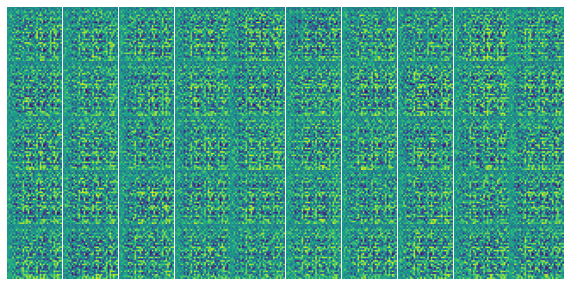

Epoch 1
		Classifier train accuracy:  0.176
		Classifier test accuracy 0.16666666666666666
		Step time:  3.2033886909484863
		Epoch time:  65.8987774848938


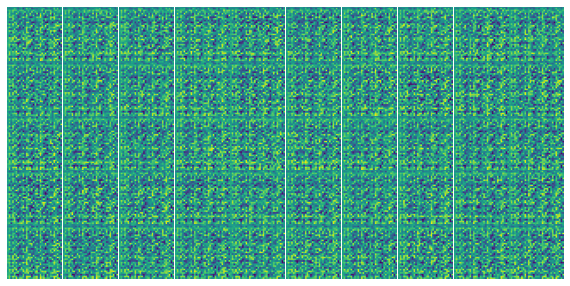

Epoch 2
		Classifier train accuracy:  0.183
		Classifier test accuracy 0.14444444444444443
		Step time:  3.2028045654296875
		Epoch time:  66.65936851501465


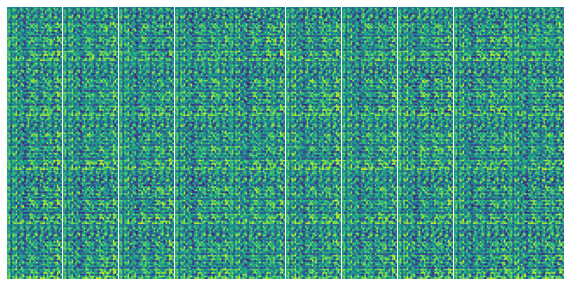

Epoch 3
		Classifier train accuracy:  0.201
		Classifier test accuracy 0.12222222222222222
		Step time:  3.6307153701782227
		Epoch time:  70.45555377006531


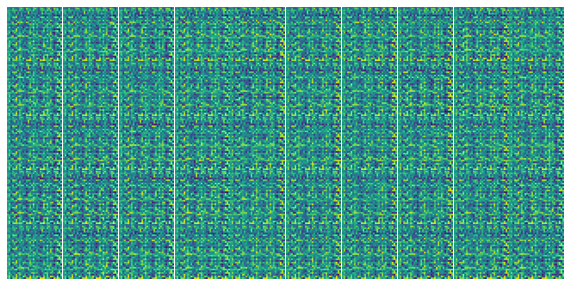

Epoch 4
		Classifier train accuracy:  0.191
		Classifier test accuracy 0.15555555555555556
		Step time:  3.892287254333496
		Epoch time:  77.45455718040466


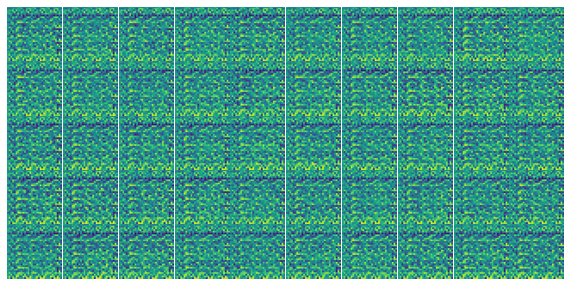

Epoch 5
		Classifier train accuracy:  0.212
		Classifier test accuracy 0.14444444444444443
		Step time:  3.232302188873291
		Epoch time:  70.27191734313965


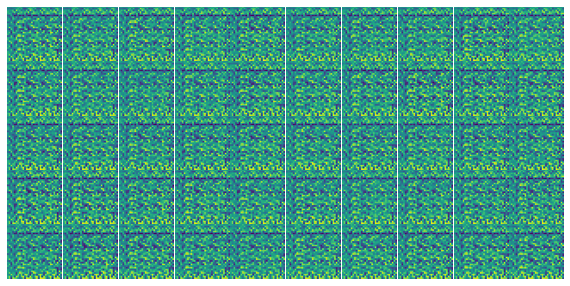

Epoch 6
		Classifier train accuracy:  0.213
		Classifier test accuracy 0.15555555555555556
		Step time:  2.960331439971924
		Epoch time:  65.19525098800659


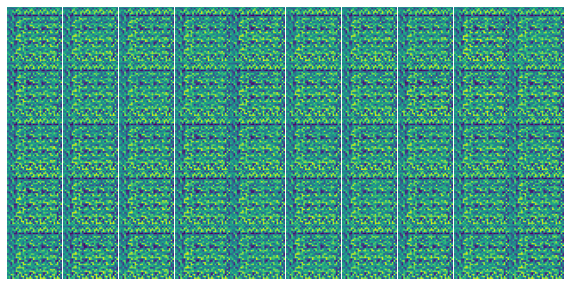

Epoch 7
		Classifier train accuracy:  0.224
		Classifier test accuracy 0.14444444444444443
		Step time:  3.008899688720703
		Epoch time:  64.12947297096252


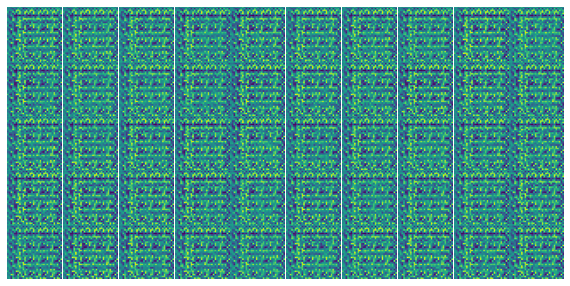

Epoch 8


KeyboardInterrupt: 

In [115]:
dataset = Dataset(trainset, testset)

batch_size = 128
epochs = 25#100
train_accuracies, test_accuracies, samples = train(net,
                                                   dataset,
                                                   epochs,
                                                   batch_size,
                                                   figsize=(10,5))

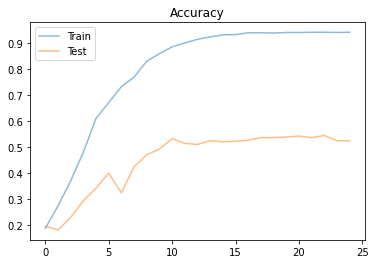

In [22]:
fig, ax = plt.subplots()
plt.plot(train_accuracies, label='Train', alpha=0.5)
plt.plot(test_accuracies, label='Test', alpha=0.5)
plt.title("Accuracy")
plt.legend()

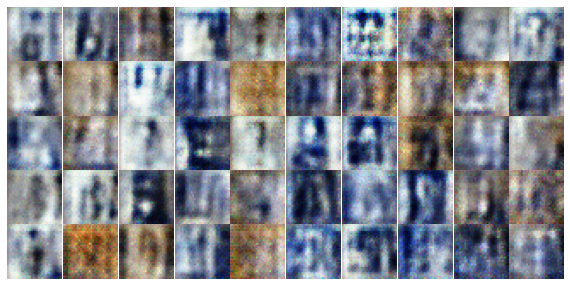

In [23]:
_ = view_samples(-1, samples, 5, 10, figsize=(10,5))

In [29]:
samples[0][0]

net.

c:\Users\Anthony\Anaconda3\lib\site-packages\keras\legacy_tf_layers\core.py:393: UserWarning: `tf.layers.dropout` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dropout` instead.
  warnings.warn('`tf.layers.dropout` is deprecated and '
c:\Users\Anthony\Anaconda3\lib\site-packages\keras\engine\base_layer_v1.py:1676: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
c:\Users\Anthony\Anaconda3\lib\site-packages\keras\legacy_tf_layers\convolutional.py:536: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  warnings.warn('`tf.layers.conv2d` is deprecated and '


ValueError: Variable discriminator/conv2d/kernel already exists, disallowed. Did you mean to set reuse=True or reuse=tf.AUTO_REUSE in VarScope?